In [9]:
from minigrad import *
from graphviz import Digraph

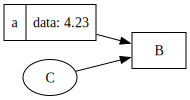

In [10]:
dot = Digraph(graph_attr={'rankdir': 'LR'})
dot.node('B', shape='record')
dot.node(name='A', label = '{a | data: 4.23}', shape='record')
dot.node('C')
dot.edge('A','B')
dot.edge('C','B')
dot

In [ ]:
def trace(root):
    nodes = set()
    edges = set()

    # use DFS, DAG so keep going till all edges explored.
    nodes.add(root)
    for child in root._prev:
        edges.add((child, root))
        n, e = trace(child)
        nodes.update(n)
        edges.update(e)

    return nodes, edges


def draw_dot(root):
    dot = Digraph(
        graph_attr={'rankdir':'LR'}
    )
    
    nodes, edges = trace(root)

    for n in nodes:
        dot.node(name=str(id(n)), label="{ %s | data: %.4f | grad: %.4f}" % (n.label, n.data, n.grad), shape='record')
        # if op node, create one
        if n._op != '':
            dot.node(name = str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))
    for a, b in edges:
        dot.edge(str(id(a)), str(id(b)) + b._op)

    return dot

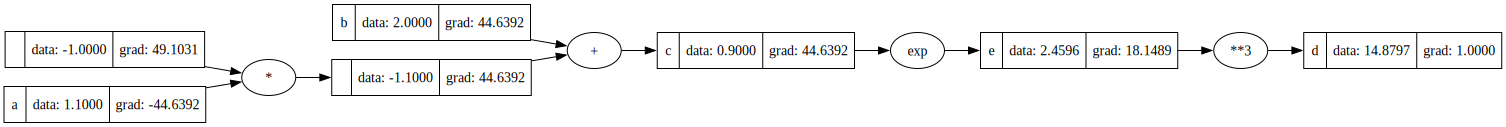

In [4]:
a = Value(1.1) ; a.label = 'a'
b = Value(2.0) ; b.label = 'b'
c = b - a ; c.label = 'c'
e = c.exp(); e.label = 'e'
d = e**3 ; d.label = 'd'

d.backward()
draw_dot(d)

In [5]:
# testing grads
h = 0.0000001

a = Value(1.1) + h; a.label = 'a'
b = Value(2.0) ; b.label = 'b'
c = b - a; c.label = 'c'
e = c.exp(); e.label = 'e'
d1 = e**3 ; d.label = 'd'
print((d1.data - d.data) / h)

-44.639188470085855


In [13]:
from nn_tensor import MLP, Layer
import numpy as np

In [14]:
 ## training
xs = [
    [0,0],
    [0,1],
    [1,1],
    [1,0]
]

ys = np.asarray([[1],[1],[1],[1]])

m = MLP(2, [2, 1])

In [15]:
y_preds = m(xs)
y_preds

Tensor(data=[[0.36572495]
 [0.53749162]
 [0.60176367]
 [0.429997  ]])

In [16]:
h = 0.01
loss_vals = []
params = m.parameters()
for epoch in range(10000):
    y_preds = m(xs)
    loss = y_preds - ys
    loss = (loss*loss).sum()

    loss_vals.append(loss.data)

    # remember to zero grad!
    for p in params:
        p.grad = np.zeros_like(p.grad)

    loss.backward()
    for p in params:
        p.data -= p.grad * h

    if epoch % 1000 == 0:
        print(f'epoch {epoch}, loss={loss.data}')

print(loss)
print(y_preds)

epoch 0, loss=1.0997144323225259
epoch 1000, loss=9.812631840083264e-05
epoch 2000, loss=1.2534145208427521e-06
epoch 3000, loss=1.5665520972690294e-08
epoch 4000, loss=1.9511377641634822e-10
epoch 5000, loss=2.4291655114501706e-12
epoch 6000, loss=3.0241741797754726e-14
epoch 7000, loss=3.764907614826472e-16
epoch 8000, loss=4.687071879679947e-18
epoch 9000, loss=5.835105315638489e-20
Tensor(data=7.2963062701561995e-22)
Tensor(data=[[1.]
 [1.]
 [1.]
 [1.]])


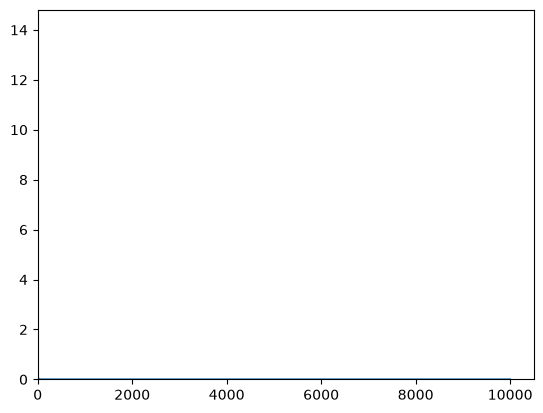

In [5]:
from matplotlib import pyplot as plt
plt.plot(loss_vals)
plt.xlim(left=0)
plt.ylim(bottom=0)
plt.show()

In [6]:
for p in params:
    print(f"Val: {p.data}, Grad: {p.grad}")

Val: [[0.88405572 0.68788414]
 [0.9095921  0.70775402]], Grad: [[-4.03718696e-15  5.18851647e-15]
 [ 3.88191054e-15 -4.98895815e-15]]
Val: [0.2282744  0.17170419], Grad: [ 7.76382109e-16 -9.97791629e-16]
Val: [[-0.17482571]
 [ 0.2246827 ]], Grad: [[-7.95564430e-16]
 [-5.92755755e-16]]
Val: [1.00132927], Grad: [-4.4408921e-15]


In [15]:
x = Tensor([1,2,3,4])

In [1]:
from minigrad import Tensor

In [2]:
(x*x).sum()

NameError: name 'x' is not defined

In [3]:
y_preds.data.T

NameError: name 'y_preds' is not defined

In [4]:
x = Tensor([[1,2],[3,4]])

In [9]:
x.exp().sum(axis=1)

Tensor(data=[10.10733793 74.68368696])

In [8]:
x.exp()

Tensor(data=[[ 2.71828183  7.3890561 ]
 [20.08553692 54.59815003]])